
# DL Assignment 03

**Name: Md.Atikur Rahaman**

**Course Email: atikurrahaman0305@gmail.com**  


## End of Assignment

Before submitting:
- Run all cells from top to bottom.  
- Check that all answer sections are filled.  
- Instruction video অনুযায়ী আমাদের দেয়া Colab ফাইলটি থেকে প্রথম একটি Save copy in drive করে নিবা। এরপর Google colab এর মধ্যে কোডগুলো করবে এবং সেই ফাইলটি 'Anyone with the link' & 'View' Access দিয়ে ফাইলটির Shareble Link টি সাবমিট করবে।

# General Instruction

You must choose your own dataset.

The dataset must:

Be a supervised learning dataset (Regression or Binary Classification)

Contain at least 300 samples

Have at least 2 input features

Be in CSV format

You are NOT allowed to use Dataset or DataLoader.

You must implement everything manually.

# Question 01: [ Marks 05 ]

## Dataset Preparation

## Using your chosen dataset:

Load the dataset.

Perform necessary preprocessing:

Handle missing values (if any)

Encode categorical variables (if necessary)

Feature scaling (if needed)

Separate features (X) and target (y).

Convert them into NumPy arrays.

Convert them into PyTorch tensors.

Split into training and testing sets.

Clearly explain each preprocessing decision.

# **Write** Answer 01:

I used the **insurance.csv** dataset. It predicts medical insurance charges based on patient info.
This is a **regression** task because charges is a continuous number.

Preprocessing steps:
- No missing values found, so no need to fill any gaps.
- `sex` and `smoker` columns have only 2 values, so I used LabelEncoder to convert them to 0 and 1.
- `region` has 4 values so I used get_dummies (one-hot encoding) to avoid wrong ordering.
- I applied StandardScaler on features because neural networks train better when inputs have similar scale.
- I also scaled the target (charges) because values range from 1000 to 64000, which is very wide.
- I split data into 80% train and 20% test before scaling to avoid data leakage.
- Finally converted everything to float32 PyTorch tensors.

In [ ]:
# Imports
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load dataset
df = pd.read_csv('insurance.csv')
print("Shape:", df.shape)
df.head()

In [ ]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [ ]:
# Encode categorical columns
le = LabelEncoder()
df['sex']    = le.fit_transform(df['sex'])     # female=0, male=1
df['smoker'] = le.fit_transform(df['smoker'])  # no=0, yes=1

# One-hot encode region (4 categories)
df = pd.get_dummies(df, columns=['region'], drop_first=False)

print("Columns after encoding:", df.columns.tolist())
df.head()

Columns after encoding: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,False,True
1,18,1,33.770,1,0,1725.55230,False,False,True,False
2,28,1,33.000,3,0,4449.46200,False,False,True,False
3,33,1,22.705,0,0,21984.47061,False,True,False,False
4,32,1,28.880,0,0,3866.85520,False,True,False,False


In [ ]:
# Separate features and target
X = df.drop(columns=['charges']).values.astype(np.float32)
y = df['charges'].values.astype(np.float32).reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1338, 9)
y shape: (1338, 1)


In [ ]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)

X_train shape: (1070, 9)
X_test  shape: (268, 9)


In [ ]:
# Feature scaling
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test  = scaler_X.transform(X_test)

# Scale target
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train)
y_test  = scaler_y.transform(y_test)

In [ ]:
# Convert to PyTorch tensors
X_train_tensor = torch.from_numpy(X_train.astype(np.float32))
X_test_tensor  = torch.from_numpy(X_test.astype(np.float32))
y_train_tensor = torch.from_numpy(y_train.astype(np.float32))
y_test_tensor  = torch.from_numpy(y_test.astype(np.float32))

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("dtype:", X_train_tensor.dtype)

X_train_tensor shape: torch.Size([1070, 9])
y_train_tensor shape: torch.Size([1070, 1])
dtype: torch.float32


# Question 02: [ Marks 20 ]

## Design a neural network using nn.Module.

### The model must contain:

Input layer

At least one hidden layer

Output layer

Suitable activation function



## Justify:

Number of hidden neurons

Choice of activation function

Print  the total number of trainable parameters.


## Write Answer 02:

I designed a neural network with 3 layers using nn.Module:
- Input layer: 9 neurons (one for each feature)
- Hidden layer 1: 64 neurons
- Hidden layer 2: 32 neurons
- Output layer: 1 neuron (predicted charge)

Why 64 and 32 neurons?
- I chose 64 for the first hidden layer because there are 9 input features and the data has some complex patterns like smoker and bmi together affecting charges.
- I chose 32 for the second layer to gradually reduce and summarize the learned features.
- This is a common funnel pattern and works well for tabular data.

Why ReLU activation?
- ReLU is the most popular activation for hidden layers.
- It helps the model learn nonlinear patterns.
- It is simple and fast, and avoids the vanishing gradient problem.

Why no activation on output?
- This is a regression task, so the output should be a free number (not between 0 and 1).
- No activation means linear output.

In [ ]:
# Define the model using nn.Module
class InsuranceNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(num_features, 64),  # Input to Hidden 1
            nn.ReLU(),
            nn.Linear(64, 32),            # Hidden 1 to Hidden 2
            nn.ReLU(),
            nn.Linear(32, 1)              # Hidden 2 to Output
        )

    def forward(self, x):
        return self.network(x)


num_features = X_train_tensor.shape[1]  # 9 features
model = InsuranceNN(num_features)
print(model)

InsuranceNN(
  (network): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [ ]:
# Print total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

for name, param in model.named_parameters():
    print(f"  {name:30s}  shape={str(param.shape):20s}  params={param.numel()}")

Total trainable parameters: 2753
  network.0.weight                shape=torch.Size([64, 9])   params=576
  network.0.bias                  shape=torch.Size([64])      params=64
  network.2.weight                shape=torch.Size([32, 64])  params=2048
  network.2.bias                  shape=torch.Size([32])      params=32
  network.4.weight                shape=torch.Size([1, 32])   params=32
  network.4.bias                  shape=torch.Size([1])       params=1


# Question 03: [ Marks 10 ]

Choose an appropriate loss function.

Choose an optimizer.

<br>

Justify your choices based on:

Regression vs Classification

Nature of the dataset

## Write Answer 03:

**Loss function: MSELoss (Mean Squared Error)**

This is a regression task so I picked MSE.
- MSE calculates the average of squared differences between predicted and actual values.
- It works well for regression because the output is a continuous number.
- It penalizes large errors more, which helps the model avoid big mistakes.

**Optimizer: Adam with learning rate 0.001**

I chose Adam because:
- It works well for most neural network tasks.
- It automatically adjusts the learning rate for each weight.
- It usually converges faster than plain SGD.
- Learning rate 0.001 is a good default starting point for Adam.

In [ ]:
# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Loss:", criterion)
print("Optimizer:", optimizer)

Loss: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


# Question 04: [ Marks 15 ]

## Implement a full training loop:

Forward pass

Loss computation

Backward pass

Parameter update

Gradient reset

### Requirements:

Train for at least 100 epochs.

Print loss every 10 epochs.

Store training loss history(You can pick your own Data Structure).

Explain clearly what happens in each step of the pipeline.

## Write Answer 04:

The training loop has 5 steps in each epoch:

1. **Forward pass** - input goes through the network and we get predictions.
2. **Compute loss** - we compare predictions with true values using MSE.
3. **Zero gradients** - we clear old gradients so they don't mix with new ones.
4. **Backward pass** - PyTorch calculates gradients using chain rule automatically.
5. **Update weights** - Adam optimizer changes the weights to reduce loss.

I store the loss in a Python list after each epoch.

In [ ]:
# Training loop
epochs = 200
loss_history = []  # store loss each epoch

for epoch in range(1, epochs + 1):

    # Step 1: Forward pass - get predictions
    y_pred = model(X_train_tensor)

    # Step 2: Compute loss
    loss = criterion(y_pred, y_train_tensor)

    # Step 3: Zero gradients
    optimizer.zero_grad()

    # Step 4: Backward pass - compute gradients
    loss.backward()

    # Step 5: Update weights
    optimizer.step()

    # Store loss value
    loss_history.append(loss.item())

    # Print every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch [{epoch:3d}/{epochs}]  Loss: {loss.item():.6f}")

print("Training done!")

Epoch [ 10/200]  Loss: 0.878830
Epoch [ 20/200]  Loss: 0.698784
Epoch [ 30/200]  Loss: 0.498187
Epoch [ 40/200]  Loss: 0.329330
Epoch [ 50/200]  Loss: 0.251885
Epoch [ 60/200]  Loss: 0.224142
Epoch [ 70/200]  Loss: 0.195321
Epoch [ 80/200]  Loss: 0.176917
Epoch [ 90/200]  Loss: 0.164823
Epoch [100/200]  Loss: 0.157204
Epoch [110/200]  Loss: 0.152376
Epoch [120/200]  Loss: 0.148958
Epoch [130/200]  Loss: 0.146277
Epoch [140/200]  Loss: 0.143956
Epoch [150/200]  Loss: 0.141911
Epoch [160/200]  Loss: 0.140080
Epoch [170/200]  Loss: 0.138420
Epoch [180/200]  Loss: 0.136867
Epoch [190/200]  Loss: 0.135438
Epoch [200/200]  Loss: 0.134114
Training done!


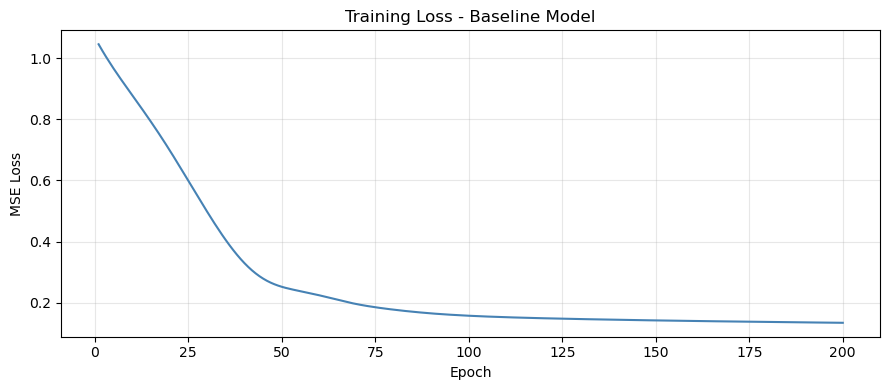

Final training loss: 0.134114


In [ ]:
# Plot training loss
plt.figure(figsize=(9, 4))
plt.plot(range(1, epochs + 1), loss_history, color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss - Baseline Model')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final training loss: {loss_history[-1]:.6f}")

# Question 05: [ Marks 10 ]

## Evaluate the model on test data.

## For regression:

Report MSE and MAE


## For classification:

Report Accuracy

Compare training vs testing performance.

State whether the model is underfitting or overfitting.

## Write Answer 05:

Since this is a regression task, I report MSE and MAE.

- MSE measures average squared error. Bigger errors are penalized more.
- MAE measures average absolute error. Easier to understand (in dollar value).

I convert predictions back to original dollar scale using inverse_transform so the MAE is easier to read.

To check overfitting:
- If test loss is much higher than train loss, model is overfitting.
- If both losses are high, model is underfitting.
- If both are similar and low, model is good.

In [ ]:
# Evaluate on test set
model.eval()

with torch.no_grad():
    y_pred_test  = model(X_test_tensor)
    y_pred_train = model(X_train_tensor)

    # MSE in scaled space
    train_mse = criterion(y_pred_train, y_train_tensor).item()
    test_mse  = criterion(y_pred_test,  y_test_tensor).item()

    # Convert back to original dollar scale
    y_pred_orig = scaler_y.inverse_transform(y_pred_test.numpy())
    y_true_orig = scaler_y.inverse_transform(y_test_tensor.numpy())

    mae = np.mean(np.abs(y_pred_orig - y_true_orig))
    mse = np.mean((y_pred_orig - y_true_orig) ** 2)

print(f"Train MSE (scaled) : {train_mse:.6f}")
print(f"Test  MSE (scaled) : {test_mse:.6f}")
print(f"Test  MSE ($)      : {mse:,.0f}")
print(f"Test  MAE ($)      : {mae:,.0f}")

ratio = test_mse / max(train_mse, 1e-9)
if ratio < 1.3:
    print("Verdict: Good fit - model is not overfitting.")
elif ratio < 2.0:
    print("Verdict: Mild overfitting - test loss is a little higher than train loss.")
else:
    print("Verdict: Overfitting - test loss is much higher than train loss.")

Train MSE (scaled) : 0.133986
Test  MSE (scaled) : 0.147540
Test  MSE ($)      : 21,294,940
Test  MAE ($)      : 2,728
Verdict: Good fit - model is not overfitting.


# Question 06: [ Marks 20 ]

## Modify at least ONE of the following:

Learning rate

Number of hidden neurons

Number of epochs

### Train again and compare:

Convergence speed

Final performance

Explain how the change affected the model.

## Write Answer 06:

I modified two things:
- Hidden neurons: changed from 64→32 to **128→64** (bigger network)
- Epochs: changed from 200 to **400** (more training time)

I kept the learning rate the same (0.001).

I expect:
- Bigger network can learn more complex patterns so loss should be lower.
- More epochs gives the optimizer more time to converge.

After training I will compare train loss, test loss, and MAE of both models.

In [ ]:
# Modified model - bigger hidden layers
class InsuranceNN_v2(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)


model_v2   = InsuranceNN_v2(num_features)
criterion2 = nn.MSELoss()
optimizer2 = torch.optim.Adam(model_v2.parameters(), lr=0.001)

epochs_v2     = 400
loss_history2 = []

for epoch in range(1, epochs_v2 + 1):
    y_pred2 = model_v2(X_train_tensor)
    loss2   = criterion2(y_pred2, y_train_tensor)

    optimizer2.zero_grad()
    loss2.backward()
    optimizer2.step()

    loss_history2.append(loss2.item())

    if epoch % 40 == 0:
        print(f"Epoch [{epoch:3d}/{epochs_v2}]  Loss: {loss2.item():.6f}")

print("Modified model training done!")

Epoch [ 40/400]  Loss: 0.189702
Epoch [ 80/400]  Loss: 0.146844
Epoch [120/400]  Loss: 0.134888
Epoch [160/400]  Loss: 0.126159
Epoch [200/400]  Loss: 0.118531
Epoch [240/400]  Loss: 0.111773
Epoch [280/400]  Loss: 0.105494
Epoch [320/400]  Loss: 0.099281
Epoch [360/400]  Loss: 0.093107
Epoch [400/400]  Loss: 0.087240
Modified model training done!


In [ ]:
# Evaluate modified model
model_v2.eval()
with torch.no_grad():
    y_pred_v2_test  = model_v2(X_test_tensor)
    y_pred_v2_train = model_v2(X_train_tensor)

    train_mse_v2 = criterion2(y_pred_v2_train, y_train_tensor).item()
    test_mse_v2  = criterion2(y_pred_v2_test,  y_test_tensor).item()

    y_pred_v2_orig = scaler_y.inverse_transform(y_pred_v2_test.numpy())
    mae_v2 = np.mean(np.abs(y_pred_v2_orig - y_true_orig))
    mse_v2 = np.mean((y_pred_v2_orig - y_true_orig) ** 2)

print("Comparison:")
print(f"  Baseline  - Train MSE: {train_mse:.4f}  Test MSE: {test_mse:.4f}  MAE: ${mae:,.0f}")
print(f"  Modified  - Train MSE: {train_mse_v2:.4f}  Test MSE: {test_mse_v2:.4f}  MAE: ${mae_v2:,.0f}")

Comparison:
  Baseline  - Train MSE: 0.1340  Test MSE: 0.1475  MAE: $2,728
  Modified  - Train MSE: 0.0871  Test MSE: 0.1754  MAE: $2,956


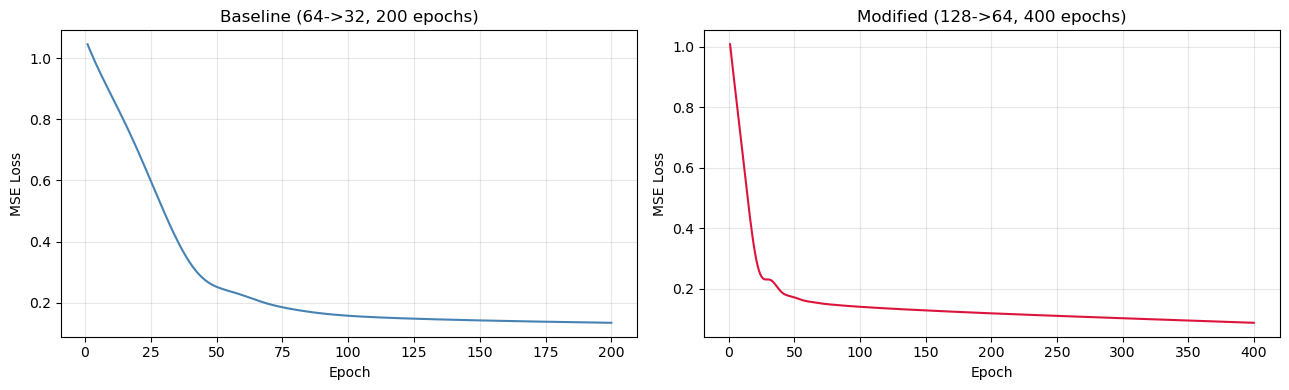

In [ ]:
# Compare loss curves side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, epochs + 1), loss_history, color='steelblue')
axes[0].set_title('Baseline (64->32, 200 epochs)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, epochs_v2 + 1), loss_history2, color='crimson')
axes[1].set_title('Modified (128->64, 400 epochs)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Question 07: [ Marks 20 ]


# Training Analysis

Answer the following:

Why must gradients be reset every epoch?

What happens if learning rate is too high?

What happens if learning rate is too small?

Why do we define layers inside the constructor (__init__) and not inside forward()?


## Write Answer 07:

**Why must gradients be reset every epoch?**

PyTorch adds gradients on top of old gradients every time backward() is called.
It does not reset automatically.
So if we don't call zero_grad(), the gradients from previous epochs pile up and become wrong.
This causes the weights to be updated using incorrect values and the model will not learn properly.
That is why we call optimizer.zero_grad() before backward() every epoch.

---

**What happens if learning rate is too high?**

The weight update will be very large.
The model will jump over the minimum loss point and not settle.
Loss will go up and down (oscillate) instead of going down smoothly.
In the worst case, loss can become NaN (model diverges).

---

**What happens if learning rate is too small?**

Each weight update will be very small.
The model will improve very slowly.
It may need many more epochs to reach a good loss.
It may also get stuck in a bad place because it cannot take big enough steps to escape.

---

**Why define layers in __init__ and not in forward()?**

When we define layers inside __init__, PyTorch registers them as part of the model.
This means:
- model.parameters() can find all weights and biases and give them to the optimizer.
- We can save and load the model weights using state_dict.
- model.to(device) moves all layers to GPU or CPU at once.

If we define layers inside forward(), a new layer is created every time forward() is called.
Those layers are not registered, so the optimizer cannot see their weights.
The model would never actually learn anything.